TensorFlow version: 2.19.0
GPU Available: []
FEDERATED LEARNING ON MNIST DATASET (Pure TensorFlow Implementation)

1. Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
   Training samples: 60000
   Test samples: 10000

2. Creating federated data for 10 clients...
Created 10 clients with IID distribution (~6000 samples each)

3. Visualizing data distribution...


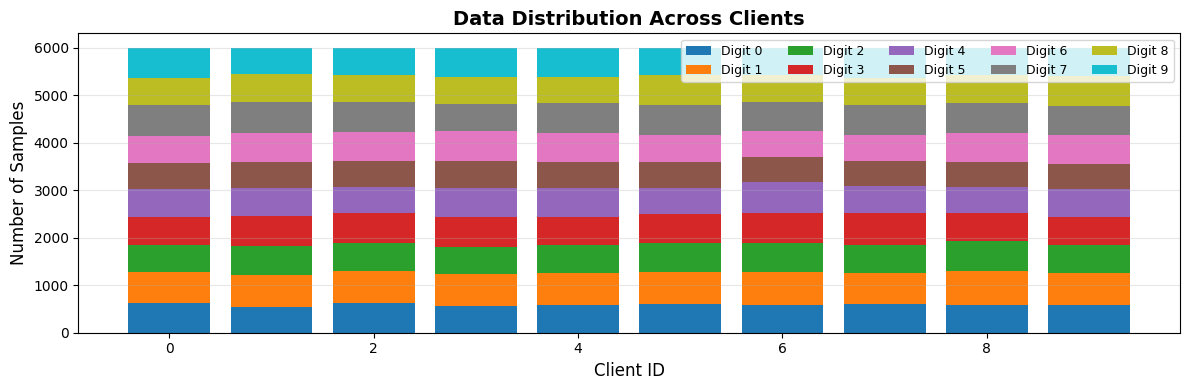


4. Running federated learning for 25 rounds...
   - Local epochs per round: 3
   - Batch size: 64
   - Learning rate: 0.02

Starting Federated Learning...

--- Round 1/25 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Client  7: Loss=0.4139, Accuracy=0.8847, Samples=6000
  Client  6: Loss=0.4954, Accuracy=0.8402, Samples=6000
  Client  1: Loss=0.4337, Accuracy=0.8665, Samples=6000
  Client  9: Loss=0.4032, Accuracy=0.8878, Samples=6000
  Client  8: Loss=0.4215, Accuracy=0.8805, Samples=6000
  Client  5: Loss=0.4486, Accuracy=0.8588, Samples=6000
  Client  2: Loss=0.4203, Accuracy=0.8827, Samples=6000
  Client  3: Loss=0.4110, Accuracy=0.8887, Samples=6000
  Client  0: Loss=0.3975, Accuracy=0.8905, Samples=6000
  Client  4: Loss=0.4453, Accuracy=0.8750, Samples=6000

  Global Model - Test Loss: 0.3918, Test Accuracy: 0.8980
  Avg Train Loss: 0.4290, Avg Train Accuracy: 0.8755

--- Round 2/25 ---
  Client  7: Loss=0.2527, Accuracy=0.9267, Samples=6000
  Client  3: Loss=0.2618, Accuracy=0.9255, Samples=6000
  Client  8: Loss=0.2887, Accuracy=0.9092, Samples=6000
  Client  6: Loss=0.2852, Accuracy=0.9138, Samples=6000
  Client  2: Loss=0.2587, Accuracy=0.9217, Samples=6000
  Client  9: Loss=0.2528, Ac

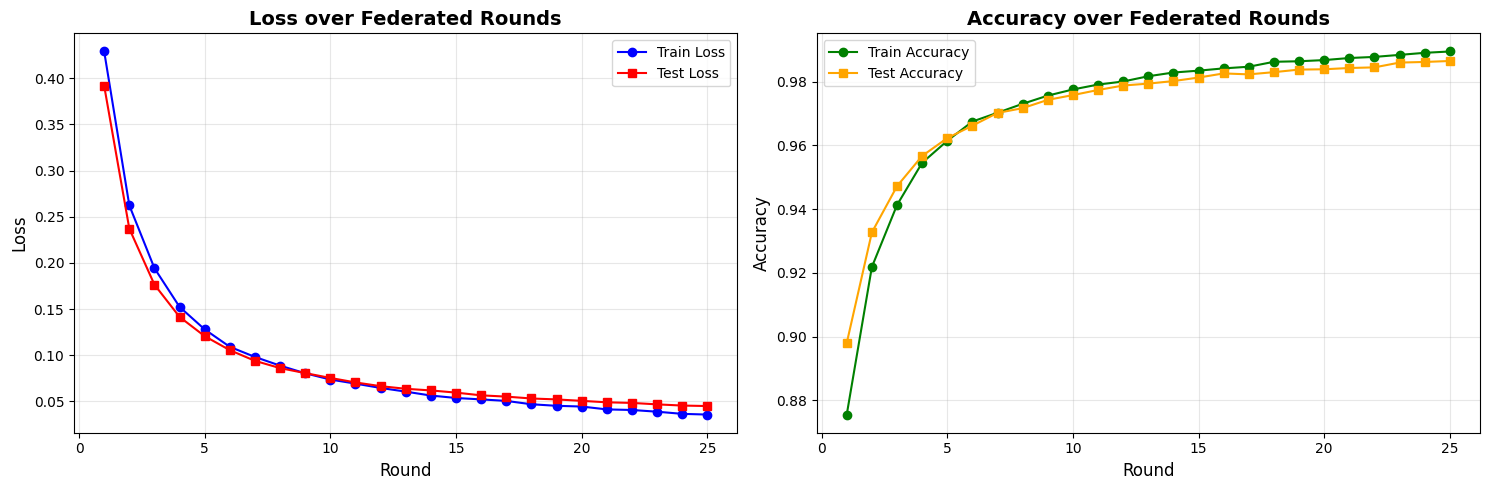


FINAL RESULTS
Final Test Loss: 0.0450
Final Test Accuracy: 0.9865 (98.65%)


In [ ]:
# Federated Learning on MNIST - Pure TensorFlow Implementation
# No tensorflow-federated dependency required!

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from typing import List, Tuple
import copy

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ==================== Configuration ====================
NUM_CLIENTS = 10          # Keep 10 clients (good for realistic FL simulation)
NUM_ROUNDS = 25           # Reduced from 50 (sufficient for convergence)
LOCAL_EPOCHS = 3          # Reduced from 5 (faster, still effective)
BATCH_SIZE = 64           # Increased from 32 (faster training)
LEARNING_RATE = 0.02      # Increased from 0.01 (faster convergence)
CLIENT_FRACTION = 1.0     # Use all clients

# ==================== Load and Preprocess MNIST ====================
def load_and_preprocess_data():
    """Load MNIST and preprocess"""
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    # Normalize pixel values to [0, 1]
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # Add channel dimension for CNN
    x_train = x_train[..., np.newaxis]
    x_test = x_test[..., np.newaxis]

    return (x_train, y_train), (x_test, y_test)

# ==================== Create Federated Data ====================
def create_federated_data(x_train, y_train, num_clients, iid=True):
    """
    Partition data among clients

    Args:
        x_train: Training images
        y_train: Training labels
        num_clients: Number of clients
        iid: If True, distribute data IID; if False, non-IID distribution

    Returns:
        List of (x, y) tuples for each client
    """
    client_data = []
    num_samples = len(x_train)

    if iid:
        # IID: Randomly shuffle and partition equally
        indices = np.random.permutation(num_samples)
        samples_per_client = num_samples // num_clients

        for i in range(num_clients):
            start_idx = i * samples_per_client
            end_idx = start_idx + samples_per_client
            client_indices = indices[start_idx:end_idx]

            client_data.append((
                x_train[client_indices],
                y_train[client_indices]
            ))

        print(f"Created {num_clients} clients with IID distribution (~{samples_per_client} samples each)")
    else:
        # Non-IID: Each client gets data from 2 digit classes
        digits_per_client = 2
        sorted_indices = np.argsort(y_train)

        for i in range(num_clients):
            digit1 = (i * digits_per_client) % 10
            digit2 = (i * digits_per_client + 1) % 10

            digit1_indices = sorted_indices[y_train[sorted_indices] == digit1]
            digit2_indices = sorted_indices[y_train[sorted_indices] == digit2]

            client_indices = np.concatenate([digit1_indices, digit2_indices])
            np.random.shuffle(client_indices)

            # Take subset
            num_client_samples = len(client_indices) // 2
            client_indices = client_indices[:num_client_samples]

            client_data.append((
                x_train[client_indices],
                y_train[client_indices]
            ))

        print(f"Created {num_clients} clients with Non-IID distribution")

    return client_data

# ==================== Create Model ====================
def create_model():
    """Create a CNN model for MNIST classification"""
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==================== Federated Learning Functions ====================
def get_model_weights(model):
    """Extract model weights"""
    return model.get_weights()

def set_model_weights(model, weights):
    """Set model weights"""
    model.set_weights(weights)

def federated_averaging(client_weights_list, client_sizes):
    """
    Perform federated averaging (FedAvg algorithm)

    Args:
        client_weights_list: List of model weights from each client
        client_sizes: List of dataset sizes for each client (for weighted averaging)

    Returns:
        Averaged model weights
    """
    total_size = sum(client_sizes)

    # Initialize averaged weights with zeros
    averaged_weights = [np.zeros_like(w) for w in client_weights_list[0]]

    # Weighted average
    for client_weights, client_size in zip(client_weights_list, client_sizes):
        weight_factor = client_size / total_size
        for i in range(len(averaged_weights)):
            averaged_weights[i] += client_weights[i] * weight_factor

    return averaged_weights

def client_update(client_model, x_client, y_client, local_epochs):
    """
    Train model on client's local data

    Args:
        client_model: Model for training
        x_client: Client's training images
        y_client: Client's training labels
        local_epochs: Number of local training epochs

    Returns:
        Updated model weights and number of samples
    """
    # Train on client data
    history = client_model.fit(
        x_client, y_client,
        batch_size=BATCH_SIZE,
        epochs=local_epochs,
        verbose=0,
        validation_split=0.0
    )

    return client_model.get_weights(), len(x_client)

# ==================== Main Federated Learning Loop ====================
def run_federated_learning(client_data, test_data, num_rounds=50):
    """
    Run federated learning for specified number of rounds

    Args:
        client_data: List of (x, y) tuples for each client
        test_data: Test dataset (x_test, y_test)
        num_rounds: Number of federated rounds

    Returns:
        Training history
    """
    x_test, y_test = test_data

    # Initialize global model
    global_model = create_model()

    # Metrics tracking
    history = {
        'round': [],
        'train_loss': [],
        'train_accuracy': [],
        'test_loss': [],
        'test_accuracy': []
    }

    print("\nStarting Federated Learning...")
    print("=" * 80)

    for round_num in range(1, num_rounds + 1):
        print(f"\n--- Round {round_num}/{num_rounds} ---")

        # Select clients for this round
        num_selected_clients = max(1, int(NUM_CLIENTS * CLIENT_FRACTION))
        selected_clients = np.random.choice(NUM_CLIENTS, num_selected_clients, replace=False)

        client_weights_list = []
        client_sizes = []
        client_losses = []
        client_accuracies = []

        # Client updates
        for client_id in selected_clients:
            # Create client model with current global weights
            client_model = create_model()
            set_model_weights(client_model, get_model_weights(global_model))

            # Get client data
            x_client, y_client = client_data[client_id]

            # Local training
            updated_weights, num_samples = client_update(
                client_model, x_client, y_client, LOCAL_EPOCHS
            )

            # Evaluate client model
            loss, accuracy = client_model.evaluate(x_client, y_client, verbose=0)

            client_weights_list.append(updated_weights)
            client_sizes.append(num_samples)
            client_losses.append(loss)
            client_accuracies.append(accuracy)

            print(f"  Client {client_id:2d}: Loss={loss:.4f}, Accuracy={accuracy:.4f}, Samples={num_samples}")

        # Federated averaging
        averaged_weights = federated_averaging(client_weights_list, client_sizes)
        set_model_weights(global_model, averaged_weights)

        # Evaluate global model on test set
        test_loss, test_accuracy = global_model.evaluate(x_test, y_test, verbose=0)

        # Calculate average training metrics
        avg_train_loss = np.mean(client_losses)
        avg_train_accuracy = np.mean(client_accuracies)

        # Store metrics
        history['round'].append(round_num)
        history['train_loss'].append(avg_train_loss)
        history['train_accuracy'].append(avg_train_accuracy)
        history['test_loss'].append(test_loss)
        history['test_accuracy'].append(test_accuracy)

        # Print summary
        print(f"\n  Global Model - Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
        print(f"  Avg Train Loss: {avg_train_loss:.4f}, Avg Train Accuracy: {avg_train_accuracy:.4f}")

    return global_model, history

# ==================== Visualization ====================
def plot_results(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    rounds = history['round']

    # Plot losses
    axes[0].plot(rounds, history['train_loss'], label='Train Loss', color='blue', marker='o')
    axes[0].plot(rounds, history['test_loss'], label='Test Loss', color='red', marker='s')
    axes[0].set_xlabel('Round', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss over Federated Rounds', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Plot accuracies
    axes[1].plot(rounds, history['train_accuracy'], label='Train Accuracy', color='green', marker='o')
    axes[1].plot(rounds, history['test_accuracy'], label='Test Accuracy', color='orange', marker='s')
    axes[1].set_xlabel('Round', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy over Federated Rounds', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_client_distribution(client_data):
    """Visualize data distribution across clients"""
    plt.figure(figsize=(12, 4))

    client_class_counts = []
    for i, (x_client, y_client) in enumerate(client_data):
        class_counts = [np.sum(y_client == digit) for digit in range(10)]
        client_class_counts.append(class_counts)

    client_class_counts = np.array(client_class_counts).T

    x = np.arange(NUM_CLIENTS)
    bottom = np.zeros(NUM_CLIENTS)

    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for digit in range(10):
        plt.bar(x, client_class_counts[digit], bottom=bottom, label=f'Digit {digit}', color=colors[digit])
        bottom += client_class_counts[digit]

    plt.xlabel('Client ID', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.title('Data Distribution Across Clients', fontsize=14, fontweight='bold')
    plt.legend(ncol=5, fontsize=9)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# ==================== Main Execution ====================
def main():
    print("=" * 80)
    print("FEDERATED LEARNING ON MNIST DATASET (Pure TensorFlow Implementation)")
    print("=" * 80)

    # Load data
    print("\n1. Loading MNIST dataset...")
    (x_train, y_train), (x_test, y_test) = load_and_preprocess_data()
    print(f"   Training samples: {len(x_train)}")
    print(f"   Test samples: {len(x_test)}")

    # Create federated data
    print(f"\n2. Creating federated data for {NUM_CLIENTS} clients...")
    client_data = create_federated_data(x_train, y_train, NUM_CLIENTS, iid=True)

    # Visualize data distribution
    print("\n3. Visualizing data distribution...")
    plot_client_distribution(client_data)

    # Run federated learning
    print(f"\n4. Running federated learning for {NUM_ROUNDS} rounds...")
    print(f"   - Local epochs per round: {LOCAL_EPOCHS}")
    print(f"   - Batch size: {BATCH_SIZE}")
    print(f"   - Learning rate: {LEARNING_RATE}")

    global_model, history = run_federated_learning(
        client_data,
        (x_test, y_test),
        num_rounds=NUM_ROUNDS
    )

    # Plot results
    print("\n5. Visualizing training results...")
    plot_results(history)

    # Final evaluation
    print("\n" + "=" * 80)
    print("FINAL RESULTS")
    print("=" * 80)
    final_test_loss, final_test_accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    print(f"Final Test Loss: {final_test_loss:.4f}")
    print(f"Final Test Accuracy: {final_test_accuracy:.4f} ({final_test_accuracy*100:.2f}%)")
    print("=" * 80)

    return global_model, history

# Run the federated learning experiment
if __name__ == "__main__":
    global_model, history = main()